In [1]:
# Ячейка 1 - Импорт
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import pickle
import time

# Загружаем данные
X_train = np.load('../../data/X_train.npy')
X_test = np.load('../../data/X_test.npy')
y_train = np.load('../../data/y_train.npy')
y_test = np.load('../../data/y_test.npy')

# Загружаем модель LSTM
model_lstm = tf.keras.models.load_model('../../models/lstm_model.keras')

print(f"X_train: {X_train.shape}")
print(f"Данные загружены!")

2026-04-16 19:44:21.733794: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-16 19:44:21.734308: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-16 19:44:21.734313: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-16 19:44:21.735132: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-16 19:44:21.735146: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


X_train: (638376, 10, 5)
Данные загружены!


In [2]:
# Ячейка 2 - Подготовка данных для sklearn моделей
# Random Forest и SVM не работают с 3D данными — нужно сплющить
X_train_flat = X_train[:50000].reshape(50000, -1)  # 50k для скорости
X_test_flat = X_test[:10000].reshape(10000, -1)
y_train_small = y_train[:50000]
y_test_small = y_test[:10000]

# Нормализация для SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"Форма для sklearn: {X_train_flat.shape}")
print("Готово!")

Форма для sklearn: (50000, 50)
Готово!


In [3]:
# Ячейка 3 - Обучение и сравнение моделей
results = {}

# 1. Random Forest
print("Обучаем Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train_small)
rf_time = time.time() - start
rf_acc = accuracy_score(y_test_small, rf.predict(X_test_flat))
results['Random Forest'] = {'accuracy': rf_acc, 'time': rf_time}
print(f"Random Forest: {rf_acc:.2%} за {rf_time:.1f}с")

# 2. SVM
print("\nОбучаем SVM...")
start = time.time()
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled[:10000], y_train_small[:10000])  # SVM медленный
svm_time = time.time() - start
svm_acc = accuracy_score(y_test_small, svm.predict(X_test_scaled))
results['SVM'] = {'accuracy': svm_acc, 'time': svm_time}
print(f"SVM: {svm_acc:.2%} за {svm_time:.1f}с")

# 3. LSTM
print("\nТестируем LSTM...")
start = time.time()
lstm_pred = model_lstm.predict(X_test[:10000], verbose=0).argmax(axis=1)
lstm_time = time.time() - start
lstm_acc = accuracy_score(y_test_small, lstm_pred)
results['LSTM'] = {'accuracy': lstm_acc, 'time': lstm_time}
print(f"LSTM: {lstm_acc:.2%} за {lstm_time:.1f}с")

Обучаем Random Forest...
Random Forest: 69.88% за 2.0с

Обучаем SVM...
SVM: 59.75% за 2.0с

Тестируем LSTM...


2026-04-16 19:46:05.973882: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


LSTM: 70.05% за 2.0с


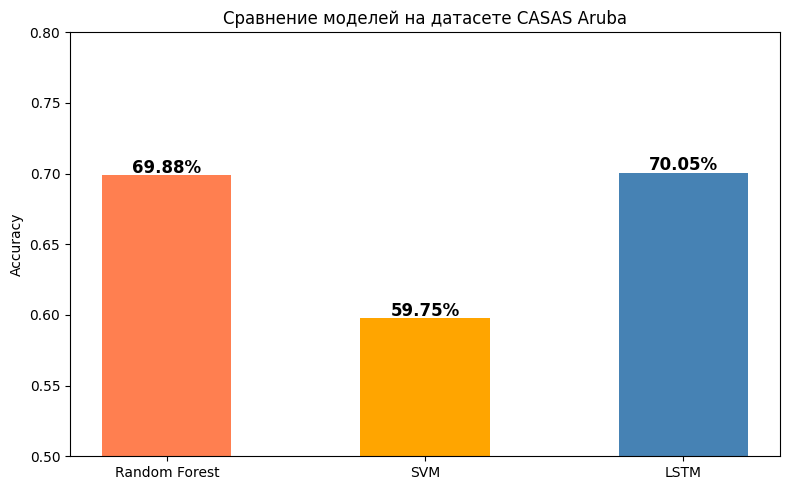


Итог:
Random Forest: 69.88%
SVM: 59.75%
LSTM: 70.05%


In [4]:
# Ячейка 4 - График сравнения
models = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models]
colors = ['coral', 'orange', 'steelblue']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(0.5, 0.8)
plt.title('Сравнение моделей на датасете CASAS Aruba')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nИтог:")
for m, r in results.items():
    print(f"{m}: {r['accuracy']:.2%}")

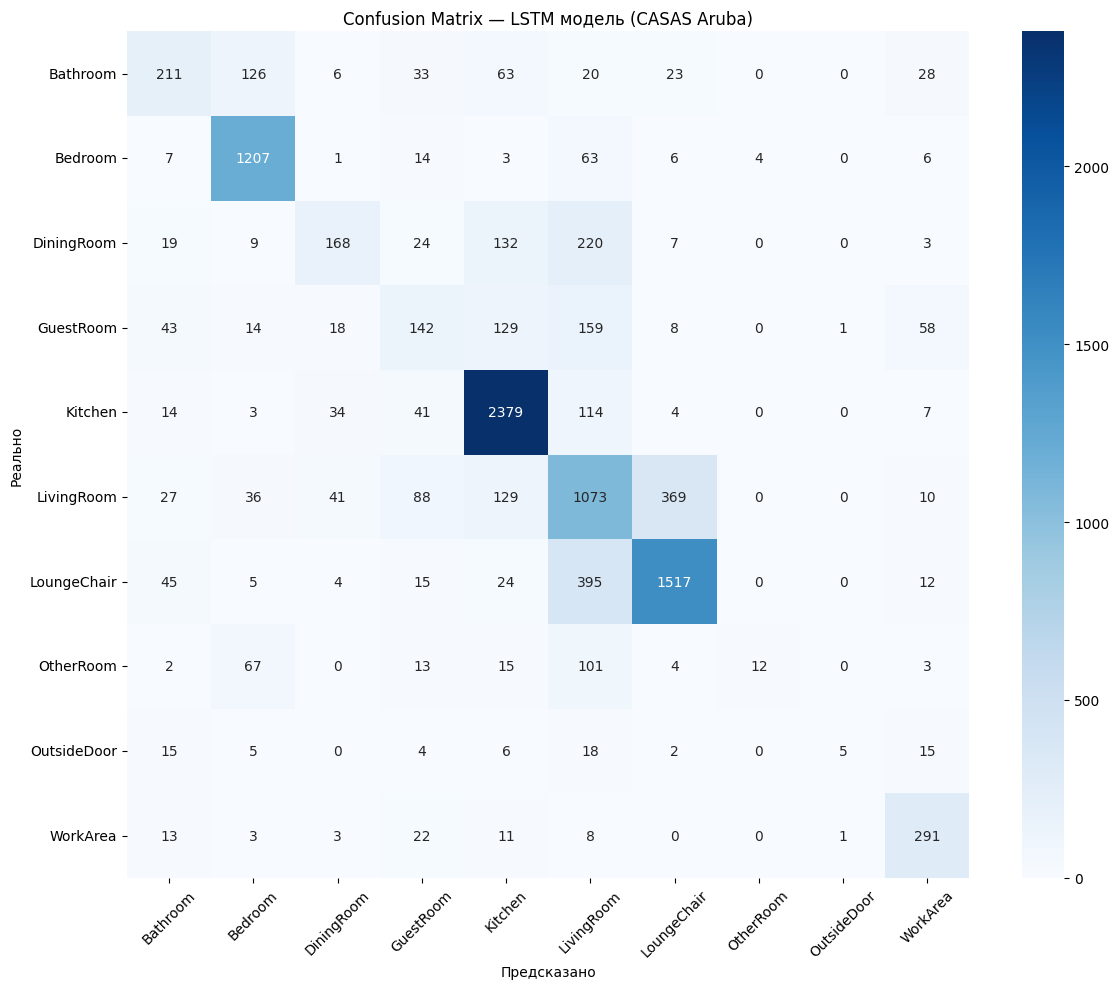

In [6]:
# Ячейка 5 - Confusion Matrix для LSTM
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pickle

with open('../../data/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

cm = confusion_matrix(y_test_small, lstm_pred)
sensor_names = list(le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sensor_names,
            yticklabels=sensor_names)
plt.title('Confusion Matrix — LSTM модель (CASAS Aruba)')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()